In [3]:
# importando librerias necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [4]:
data = pd.read_csv('1.01. Simple linear regression.csv')

In [5]:
data.describe()

,SAT,GPA
count,84.000000,84.000000
mean,1845.273810,3.330238
std,104.530661,0.271617
min,1634.000000,2.400000
25%,1772.000000,3.190000
50%,1846.000000,3.380000
75%,1934.000000,3.502500
max,2050.000000,3.810000


In [8]:
y = data['GPA'] # variable dependiente o estimada 
x1 = data['SAT'] # variable independiente o estimadora

### EDA


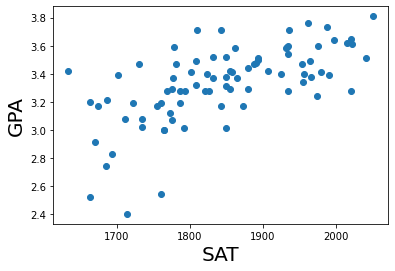

In [9]:
plt.scatter(x1,y)
plt.xlabel('SAT', fontsize = 20)
plt.ylabel('GPA', fontsize = 20)
plt.show()

### Analisis visual


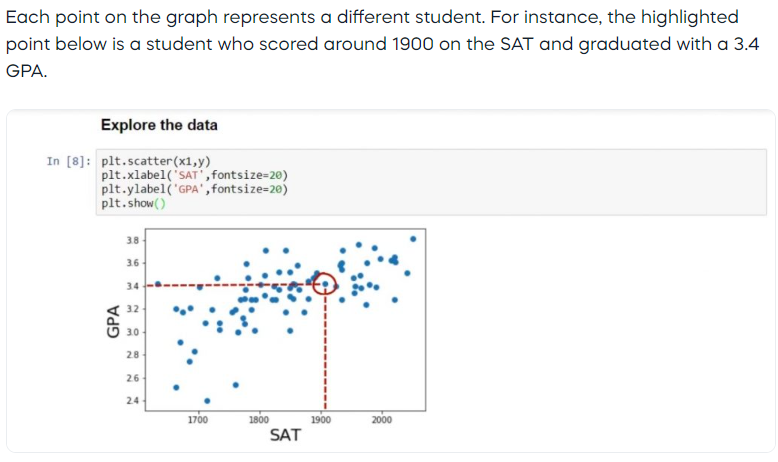

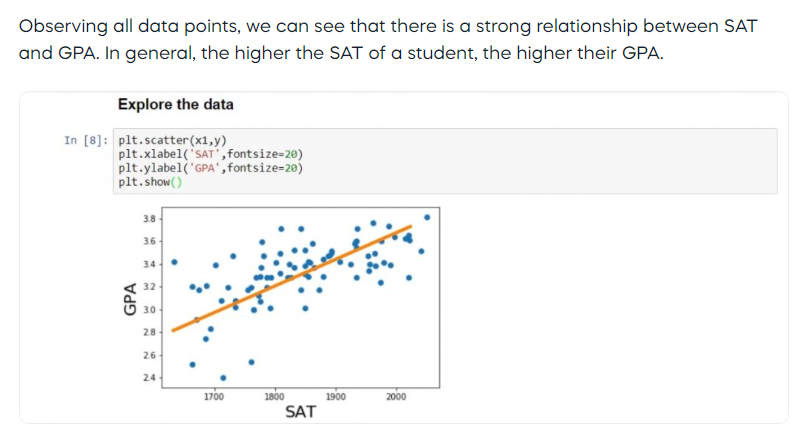

It is really practical for computational purposes to incorporate this notion into the equation. And that’s how we estimate the intercept b0. In terms of code, statsmodels uses the method: .add_constant().

So, let’s declare a new variable:

In [10]:
x = sm.add_constant(x1)

In [13]:
results = sm.OLS(y,x).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    GPA   R-squared:                       0.406
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     56.05
Date:                Mon, 08 Aug 2022   Prob (F-statistic):           7.20e-11
Time:                        05:30:10   Log-Likelihood:                 12.672
No. Observations:                  84   AIC:                            -21.34
Df Residuals:                      82   BIC:                            -16.48
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2750      0.409      0.673      0.503      -0.538       1.088
SAT            0.0017      0.000      7.487      0.000       0.001       0.002
==============================================================================
Omnibus:                       12.839   Durbin-Watson:                   0.950
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               16.155
Skew:                          -0.722   Prob(JB):                     0.000310
Kurtosis:                       4.590   Cond. No.                     3.29e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.29e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

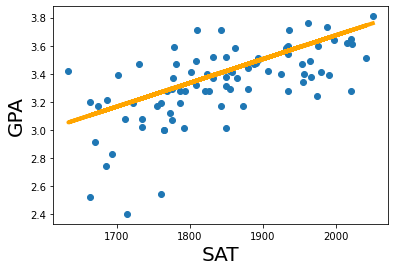

In [30]:
plt.scatter(x1,y)
# ŷ = b0 + b1*x1
yhat = 0.275 + 0.0017*x1
fig = plt.plot(x1,yhat, lw=4, c='orange', label = 'regression line')
plt.xlabel('SAT', fontsize = 20)
plt.ylabel('GPA', fontsize = 20)
plt.show()

### Cómo interpretar la tabla de regresión
Ahora, averigüemos cómo interpretar la tabla de regresión que vimos anteriormente en nuestro ejemplo de regresión lineal.

Mientras que los gráficos que hemos visto hasta ahora son agradables y fáciles de entender. Cuando realice un análisis de regresión, encontrará algo diferente a un diagrama de dispersión con una línea de regresión. El gráfico es una representación visual, y lo que realmente queremos es la ecuación del modelo y una medida de su significado y poder explicativo. Esta es la razón por la que el resumen de la regresión consta de unas pocas tablas, en lugar de un gráfico.

### Las 3 Tablas Principales
Por lo general, cuando usamos statsmodels, tendremos tres tablas principales: un resumen del modelo

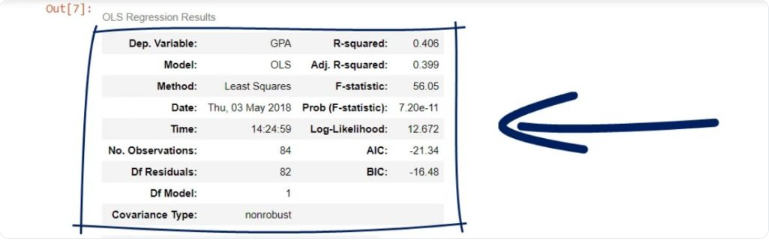

una tabla de coeficientes

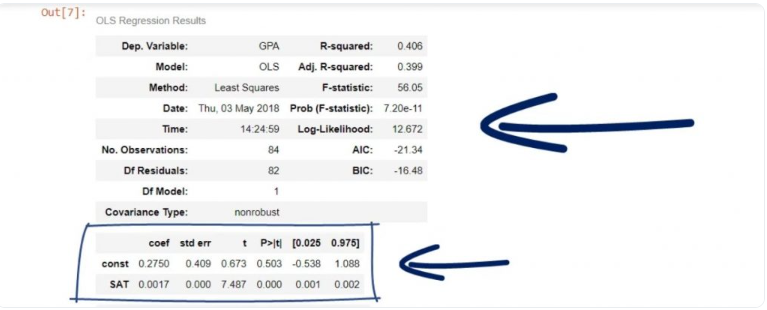

and some additional tests.

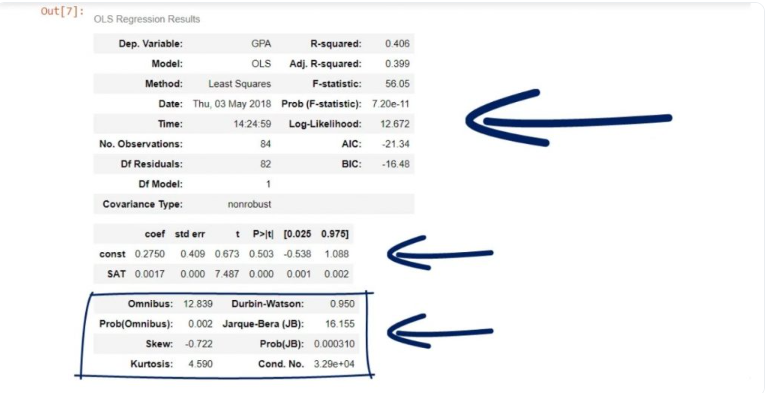

Ciertamente, estas tablas contienen mucha información, pero nos centraremos en las partes más importantes.

Comenzaremos con la tabla de coeficientes.

### La tabla de coeficientes

Podemos ver el coeficiente del intercepto, o la constante como la han llamado en nuestro caso.

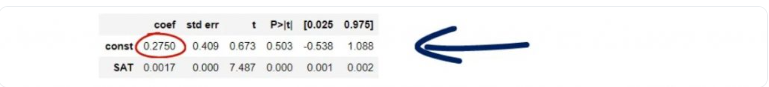

Ambos términos se usan indistintamente. En cualquier caso, es 0,275, lo que significa que b0 es 0,275.

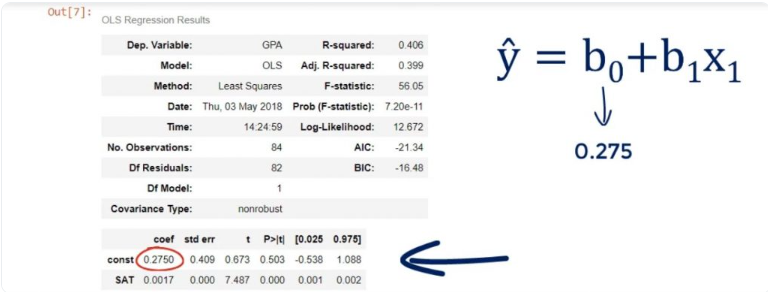

Mirando debajo, notamos que el otro coeficiente es 0.0017. Este es nuestro b1. Estos son los únicos dos números que necesitamos para definir la ecuación de regresión.

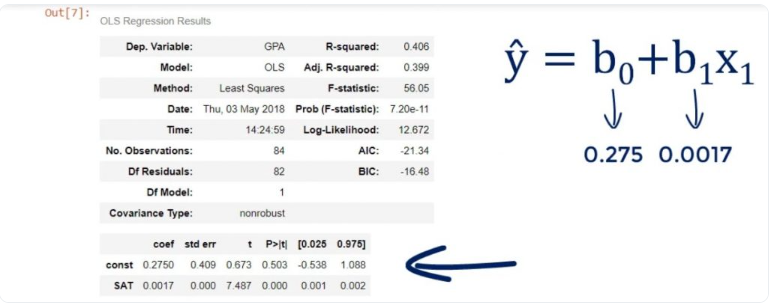

Por lo tanto,

ŷ= 0.275 + 0.0017 * x1.

O el GPA es igual a 0,275 más 0,0017 veces la puntuación del SAT.

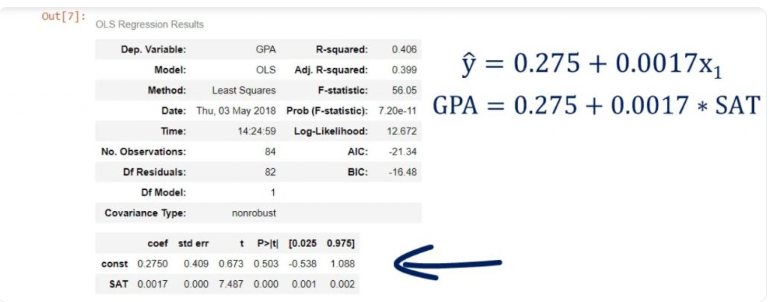

### Un resumen rápido

Demos un paso atrás y miremos el código donde trazamos la línea de regresión. Hemos trazado el diagrama de dispersión de SAT y GPA. Eso está claro. Después de eso, creamos una variable llamada: y hat(ŷ). Además, importamos la biblioteca seaborn como una "máscara" para matplotlib. Hicimos eso para mostrar la regresión de una manera más bonita.

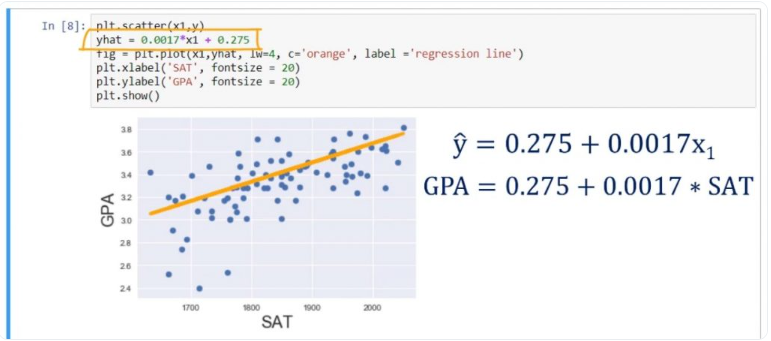

Esa es la línea de regresión: las variables predichas basadas en los datos

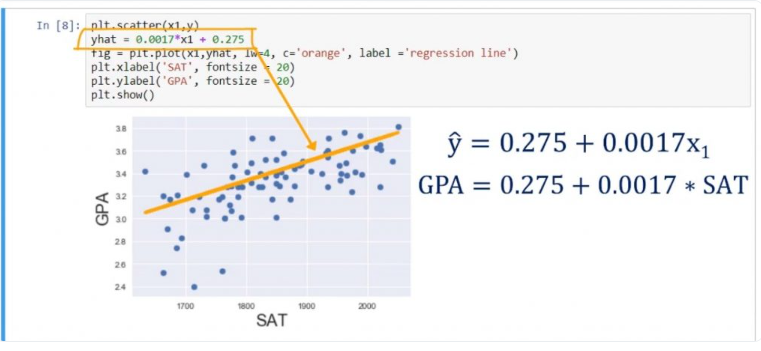

Naturalmente, elegimos los coeficientes de la tabla de coeficientes, no los inventamos.

## El poder predictivo de las regresiones lineales

Quizás se pregunte si esa predicción es útil. Bien, sabiendo que una persona ha sacado 1700 en el SAT, podemos sustituir en la ecuación y obtener lo siguiente:

0,275 + 0,0017 * 1700, lo que equivale a 3,165. Entonces, el GPA esperado para este estudiante, según nuestro modelo, es 3.165.

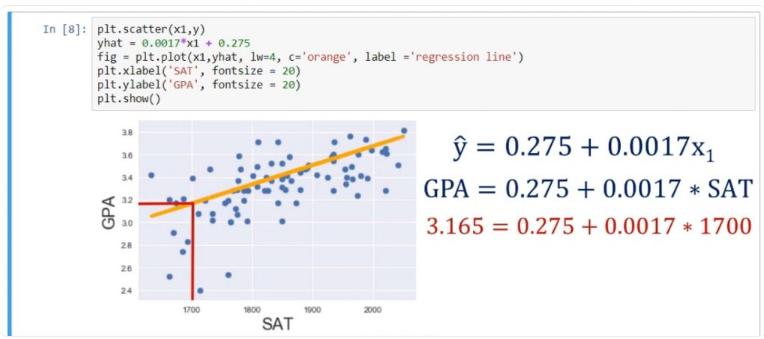

¡Y ese es el poder predictivo de las regresiones lineales en pocas palabras!

## Los errores estándar

¿Qué pasa con las otras celdas de la tabla?

Los errores estándar muestran la precisión de la predicción para cada variable.

¡Cuanto menor sea el error estándar, mejor será la estimación!

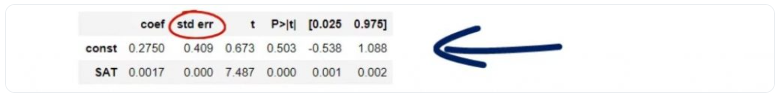

## La estadística T

Los siguientes dos valores son una estadística T y su valor P.

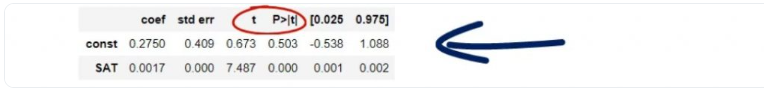

La hipótesis nula de esta prueba es: β = 0. En otras palabras, ¿el coeficiente es igual a cero?

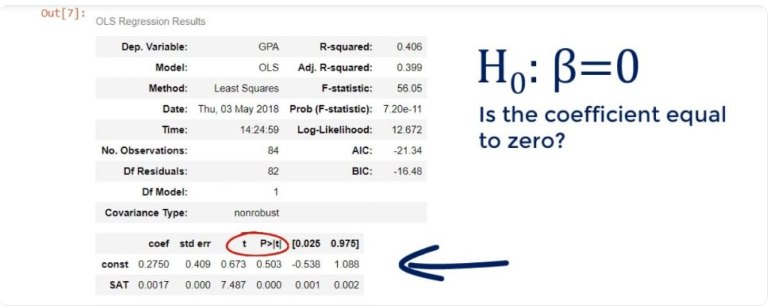

### La hipótesis nula

Si un coeficiente es cero para la intersección (b0), entonces la línea cruza el eje y en el origen. Puede obtener una mejor comprensión de lo que estamos hablando, a partir de la imagen a continuación:

### ŷ = b0 + b1x1
### ŷ = 0 + 0.0017 * x1.

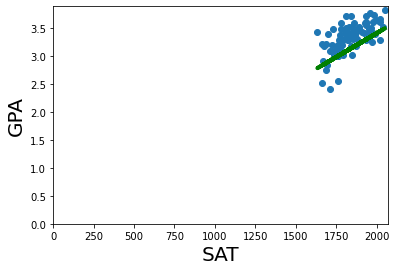

In [29]:
plt.scatter(x1,y)
# ŷ = b0 + b1*x1
yhat = 0 + 0.0017*x1 
fig = plt.plot(x1,yhat, lw=4, c='green', label = 'regression line')
plt.xlabel('SAT', fontsize = 20)
plt.ylabel('GPA', fontsize = 20)
plt.xlim(0)
plt.ylim(0)
plt.show()

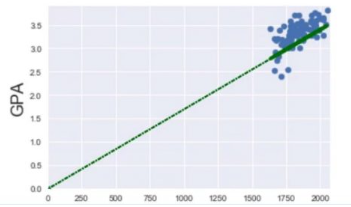

Si β1 es cero, entonces 0 * x siempre será 0 para cualquier x, por lo que esta variable no se considerará para el modelo. Gráficamente, eso significaría que la línea de regresión es horizontal, siempre pasando por el valor de intersección.

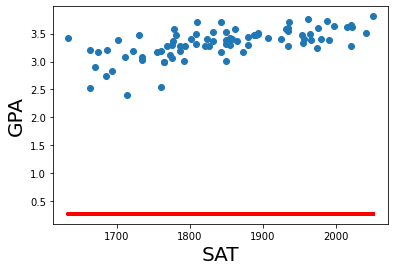

In [31]:
plt.scatter(x1,y)
# ŷ = b0 + b1*x1
yhat =  0.275 + 0*x1 
fig = plt.plot(x1,yhat, lw=4, c='red', label = 'regression line')
plt.xlabel('SAT', fontsize = 20)
plt.ylabel('GPA', fontsize = 20)
plt.show()

## El valor P

Parafraseemos esta prueba. Esencialmente, pregunta, ¿es esta una variable útil? ¿Nos ayuda a explicar la variabilidad que tenemos en este caso? La respuesta está contenida en la columna del valor P.

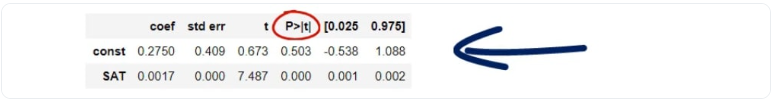

Un valor P por debajo de 0,05 significa que la variable es significativa. Por lo tanto, lo más probable es que el coeficiente sea diferente de 0


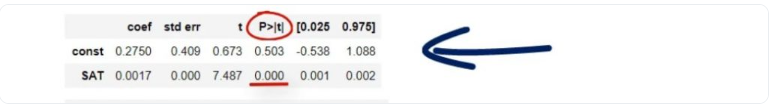

### ¿Qué significa esto para nuestro ejemplo de regresión lineal?

Bueno, simplemente nos dice que la puntuación del SAT es una variable importante al predecir el GPA universitario.

Lo que puede notar es que el valor p del intercepto no es cero.

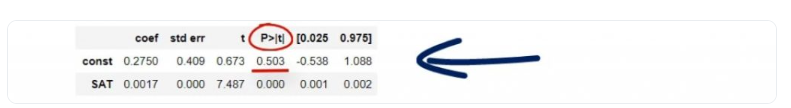

Pensemos en esto. ¿Importa tanto?<br>
Esta prueba hace la pregunta: Gráficamente, eso significaría que la línea de regresión pasa por el origen del gráfico.

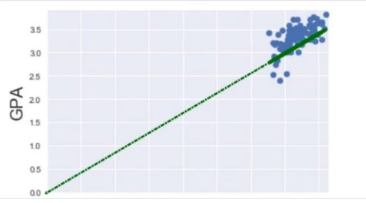

Por lo general, esto no es esencial, ya que es la relación causal de las X que nos interesan.

## La estadística F
La última medida que discutiremos es la estadística F. Explicaremos su esencia y veremos cómo nos puede ser útil.

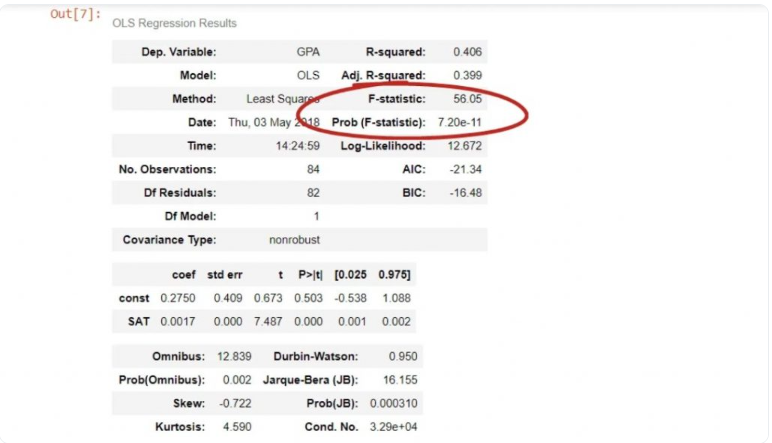

Al igual que la estadística Z que sigue una distribución normal y la estadística T que sigue una distribución T de Student, la estadística F sigue una distribución F.

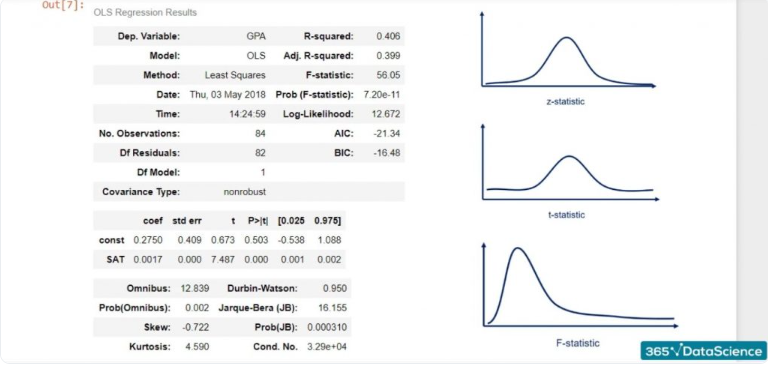

Lo llamamos estadística, lo que significa que se usa para pruebas. La prueba se conoce como la prueba de significación general del modelo.

## La hipótesis nula y la hipótesis alternativa

* La hipótesis nula es: todos los βs son iguales a cero simultáneamente.
* La hipótesis alternativa es: al menos un β difiere de cero.

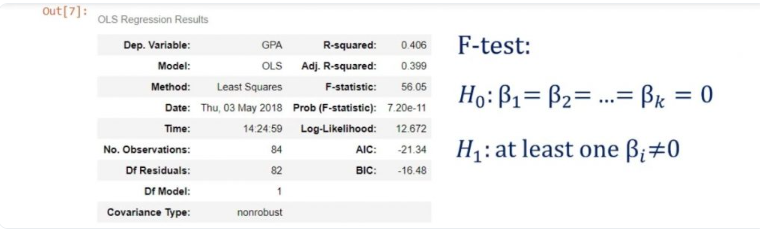

Esta es la interpretación: si todos los β son cero, entonces,

ninguna de las variables independientes importa. 

Por lo tanto, nuestro modelo no tiene ningún mérito.

En nuestro caso, el estadístico F es 56,05.

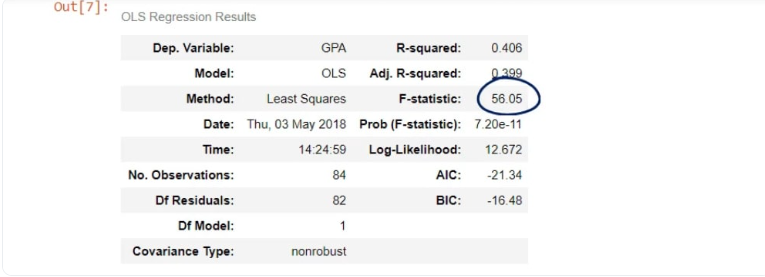

La celda de abajo es su valor P.

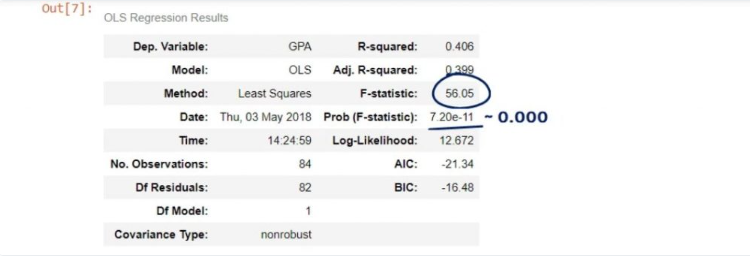

Como puede ver, el número es realmente bajo: es prácticamente 0.000. Decimos que el modelo general es significativo.

Importante: observe cómo el valor P es una medida universal para todas las pruebas. Se usa una tabla F para el estadístico F, pero no la necesitamos porque la noción del valor P es muy poderosa.

La prueba F es importante para las regresiones, ya que nos brinda información importante. Recuerde, cuanto más baja sea la estadística F, más se acercará a un modelo no significativo.

Además, ¡no olvides buscar los tres ceros después del punto!